<a href="https://colab.research.google.com/github/anikaBushra81/Artificial_Intelligence_Lab/blob/main/Earthquake_prediction1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


df = pd.read_csv("earthquakes.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)


Shape: (1137, 43)
Columns: Index(['id', 'magnitude', 'type', 'title', 'date', 'time', 'updated', 'url',
       'detailUrl', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig',
       'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'geometryType', 'depth', 'latitude', 'longitude', 'place',
       'distanceKM', 'placeOnly', 'location', 'continent', 'country',
       'subnational', 'city', 'locality', 'postcode', 'what3words', 'timezone',
       'locationDetails'],
      dtype='object')


In [ ]:
# Significant earthquake label (>= 5.0)
df['label_sig'] = (df['magnitude'] >= 5.0).astype(int)

# Drop unused columns
drop_cols = ['id','title','url','locationDetails','what3words']
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Features / Target
X = df.drop(columns=['magnitude','label_sig'])
y = df['label_sig']


In [ ]:

# Separate categorical & numeric
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# Impute
num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols)
    X_cat = pd.get_dummies(X_cat, drop_first=True)
    X_proc = pd.concat([X_num, X_cat], axis=1)
else:
    X_proc = X_num.copy()

print("Final Feature Shape:", X_proc.shape)


Final Feature Shape: (1137, 4235)



Pearson Correlation with magnitude:
 longitude     0.746729
timezone      0.730700
sig           0.717398
nst           0.666889
rms           0.600094
dmin          0.527240
mmi           0.444663
cdi           0.331727
depth         0.310034
tsunami       0.226943
distanceKM    0.097969
felt         -0.007569
postcode     -0.133547
gap          -0.245491
latitude     -0.410561
updated      -0.498503
time         -0.574277
dtype: float64


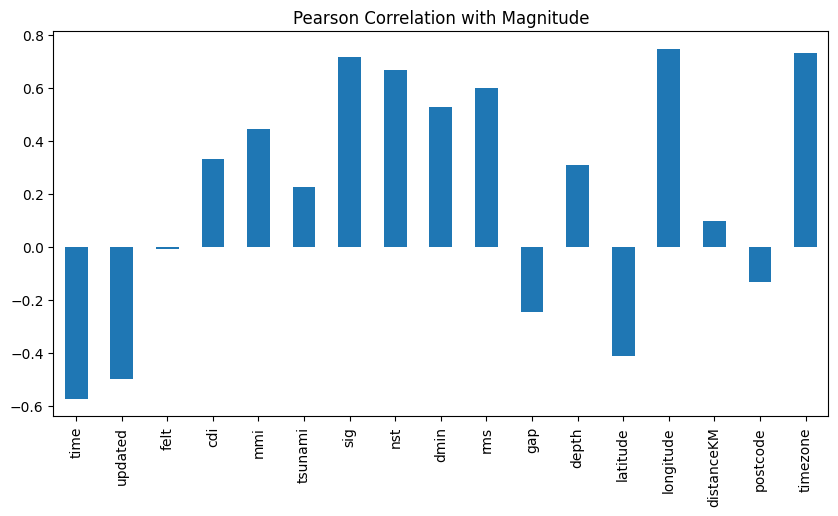

In [ ]:
#Pearson Correlation
pearson_corr = X_num.corrwith(df['magnitude'])
print("\nPearson Correlation with magnitude:\n", pearson_corr.sort_values(ascending=False))
pearson_corr.plot(kind='bar', figsize=(10,5), title="Pearson Correlation with Magnitude")
plt.show()



Information Gain Scores:
 sig                        0.570908
longitude                  0.552189
latitude                   0.543678
timezone                   0.473307
dmin                       0.448216
time                       0.442352
updated                    0.441576
nst                        0.406332
magType_mww                0.371584
depth                      0.365451
magType_ml                 0.316364
rms                        0.293142
net_us                     0.273372
continent_North America    0.255376
distanceKM                 0.229358
dtype: float64


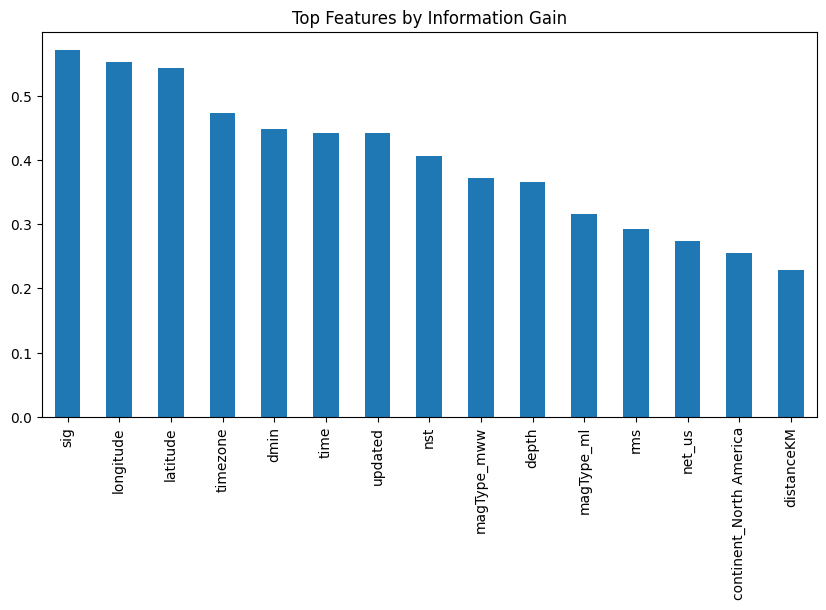

In [ ]:
#Information Gain
mi_scores = mutual_info_classif(X_proc, y)
mi_series = pd.Series(mi_scores, index=X_proc.columns).sort_values(ascending=False)
print("\nInformation Gain Scores:\n", mi_series.head(15))

mi_series.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Information Gain")
plt.show()



Gain Ratio (approx):
 sig                        1.000000
longitude                  0.967211
latitude                   0.952304
timezone                   0.829043
dmin                       0.785093
time                       0.774822
updated                    0.773463
nst                        0.711729
magType_mww                0.650864
depth                      0.640123
magType_ml                 0.554142
rms                        0.513465
net_us                     0.478838
continent_North America    0.447316
distanceKM                 0.401742
dtype: float64


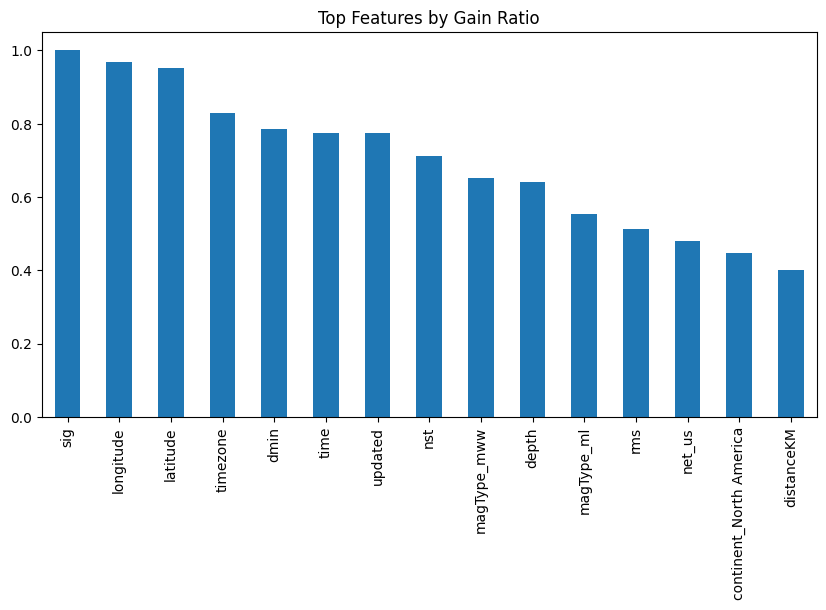

In [ ]:
#Gain Ratio
scaler = MinMaxScaler()
gain_ratio = scaler.fit_transform(mi_scores.reshape(-1,1)).flatten()
gain_ratio_series = pd.Series(gain_ratio, index=X_proc.columns).sort_values(ascending=False)
print("\nGain Ratio (approx):\n", gain_ratio_series.head(15))

gain_ratio_series.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Gain Ratio")
plt.show()



Hybrid Feature Scores:
 longitude     0.983606
sig           0.980159
timezone      0.903679
nst           0.801857
time          0.770757
latitude      0.748753
dmin          0.744075
updated       0.718821
rms           0.657543
depth         0.524662
mmi           0.370434
gap           0.319796
cdi           0.273646
distanceKM    0.262022
postcode      0.190847
dtype: float64


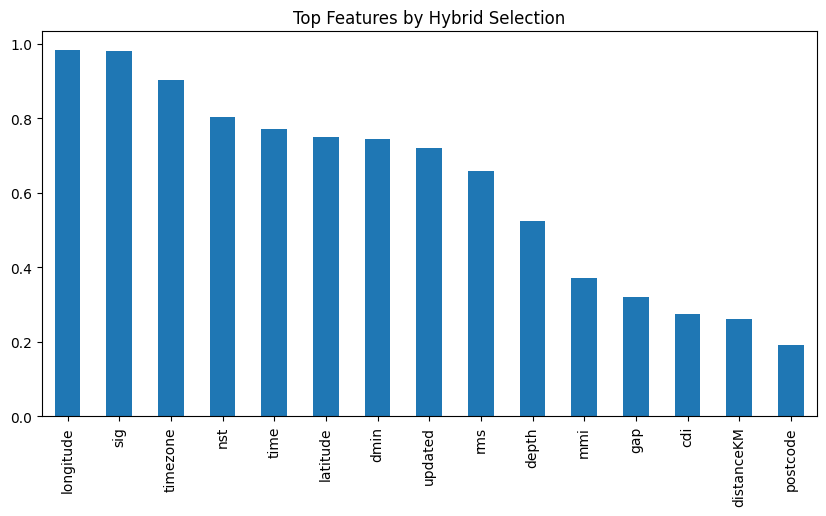

In [ ]:
#Hybrid Feature

# Normalize Pearson + MI
pearson_norm = scaler.fit_transform(abs(pearson_corr.fillna(0)).values.reshape(-1,1)).flatten()
mi_norm = scaler.fit_transform(mi_scores.reshape(-1,1)).flatten()

# Align Pearson index with X_proc
pearson_series = pd.Series(pearson_norm, index=X_num.columns)
mi_series_full = pd.Series(mi_norm, index=X_proc.columns)

# For hybrid, only common features
common_features = list(set(X_num.columns) & set(X_proc.columns))

hybrid_scores = (pearson_series[common_features] + mi_series_full[common_features]) / 2
hybrid_scores = hybrid_scores.sort_values(ascending=False)

print("\nHybrid Feature Scores:\n", hybrid_scores.head(15))

hybrid_scores.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Hybrid Selection")
plt.show()


In [ ]:
#Select top-n feature

top_features = hybrid_scores.head(10).index.tolist()
X_selected = X_proc[top_features]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# Scale
scaler_final = StandardScaler(with_mean=False)
X_train_s = scaler_final.fit_transform(X_train)
X_test_s = scaler_final.transform(X_test)


In [ ]:
#Model and Evaluation

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGB": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results[name] = {"ACC": acc, "PREC": prec, "REC": rec, "F1": f1}
    print(f"{name}: ACC={acc:.3f}, PREC={prec:.3f}, REC={rec:.3f}, F1={f1:.3f}")


LogReg: ACC=0.947, PREC=0.968, REC=0.938, F1=0.953
RF: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996
SVM: ACC=0.886, PREC=0.973, REC=0.823, F1=0.892
XGB: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996


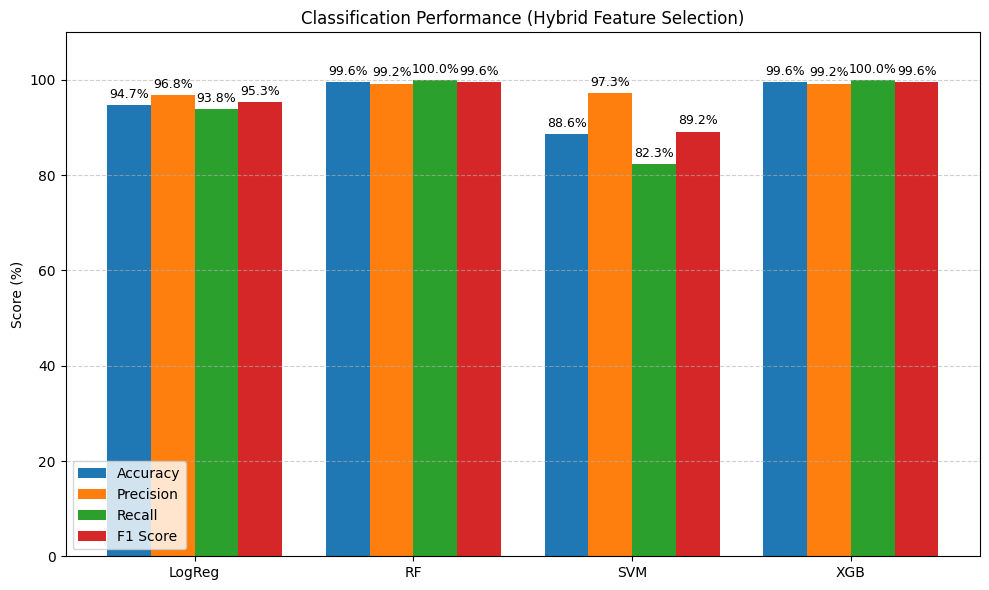

In [ ]:
#Graph


labels = list(results.keys())
acc = [results[m]['ACC']*100 for m in labels]
prec = [results[m]['PREC']*100 for m in labels]
rec = [results[m]['REC']*100 for m in labels]
f1 = [results[m]['F1']*100 for m in labels]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))
rects1 = plt.bar(x - 1.5*width, acc, width, label='Accuracy')
rects2 = plt.bar(x - 0.5*width, prec, width, label='Precision')
rects3 = plt.bar(x + 0.5*width, rec, width, label='Recall')
rects4 = plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels)
plt.ylabel("Score (%)")
plt.title("Classification Performance (Hybrid Feature Selection)")
plt.legend()
plt.ylim(0, 110)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}%',
                     xy=(rect.get_x() + rect.get_width()/2, height),
                     xytext=(0,3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
